# EDA & Preprocessing — Plan

This section performs a complete, reproducible exploratory data analysis and preprocessing pipeline so you can proceed to modeling with balanced, well-prepared datasets. Steps:

1. Load data and inspect target imbalance.
2. Visualize distributions and correlations.
3. Clean and feature-engineer (impute, transform `Amount`).
4. Scale features and compute `class_weight` for models.
5. Create resampled training sets (SMOTE, undersampling, SMOTE+Tomek).

All operations are applied only to the training set where appropriate to avoid leakage.

In [6]:
# Imports and environment checks

import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

In [7]:
# Load data and initial inspection

DATA_PATH = "data/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print('shape:', df.shape)
print('\nTarget distribution:')
if 'Class' in df.columns:
    print(df['Class'].value_counts(dropna=False))
else:
    print('No column named Class found — adjust target selection')

print('\nMissing values (top):')
print(df.isna().sum().sort_values(ascending=False).head(10))

# show a small sample
df.head()

shape: (284807, 31)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Missing values (top):
Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


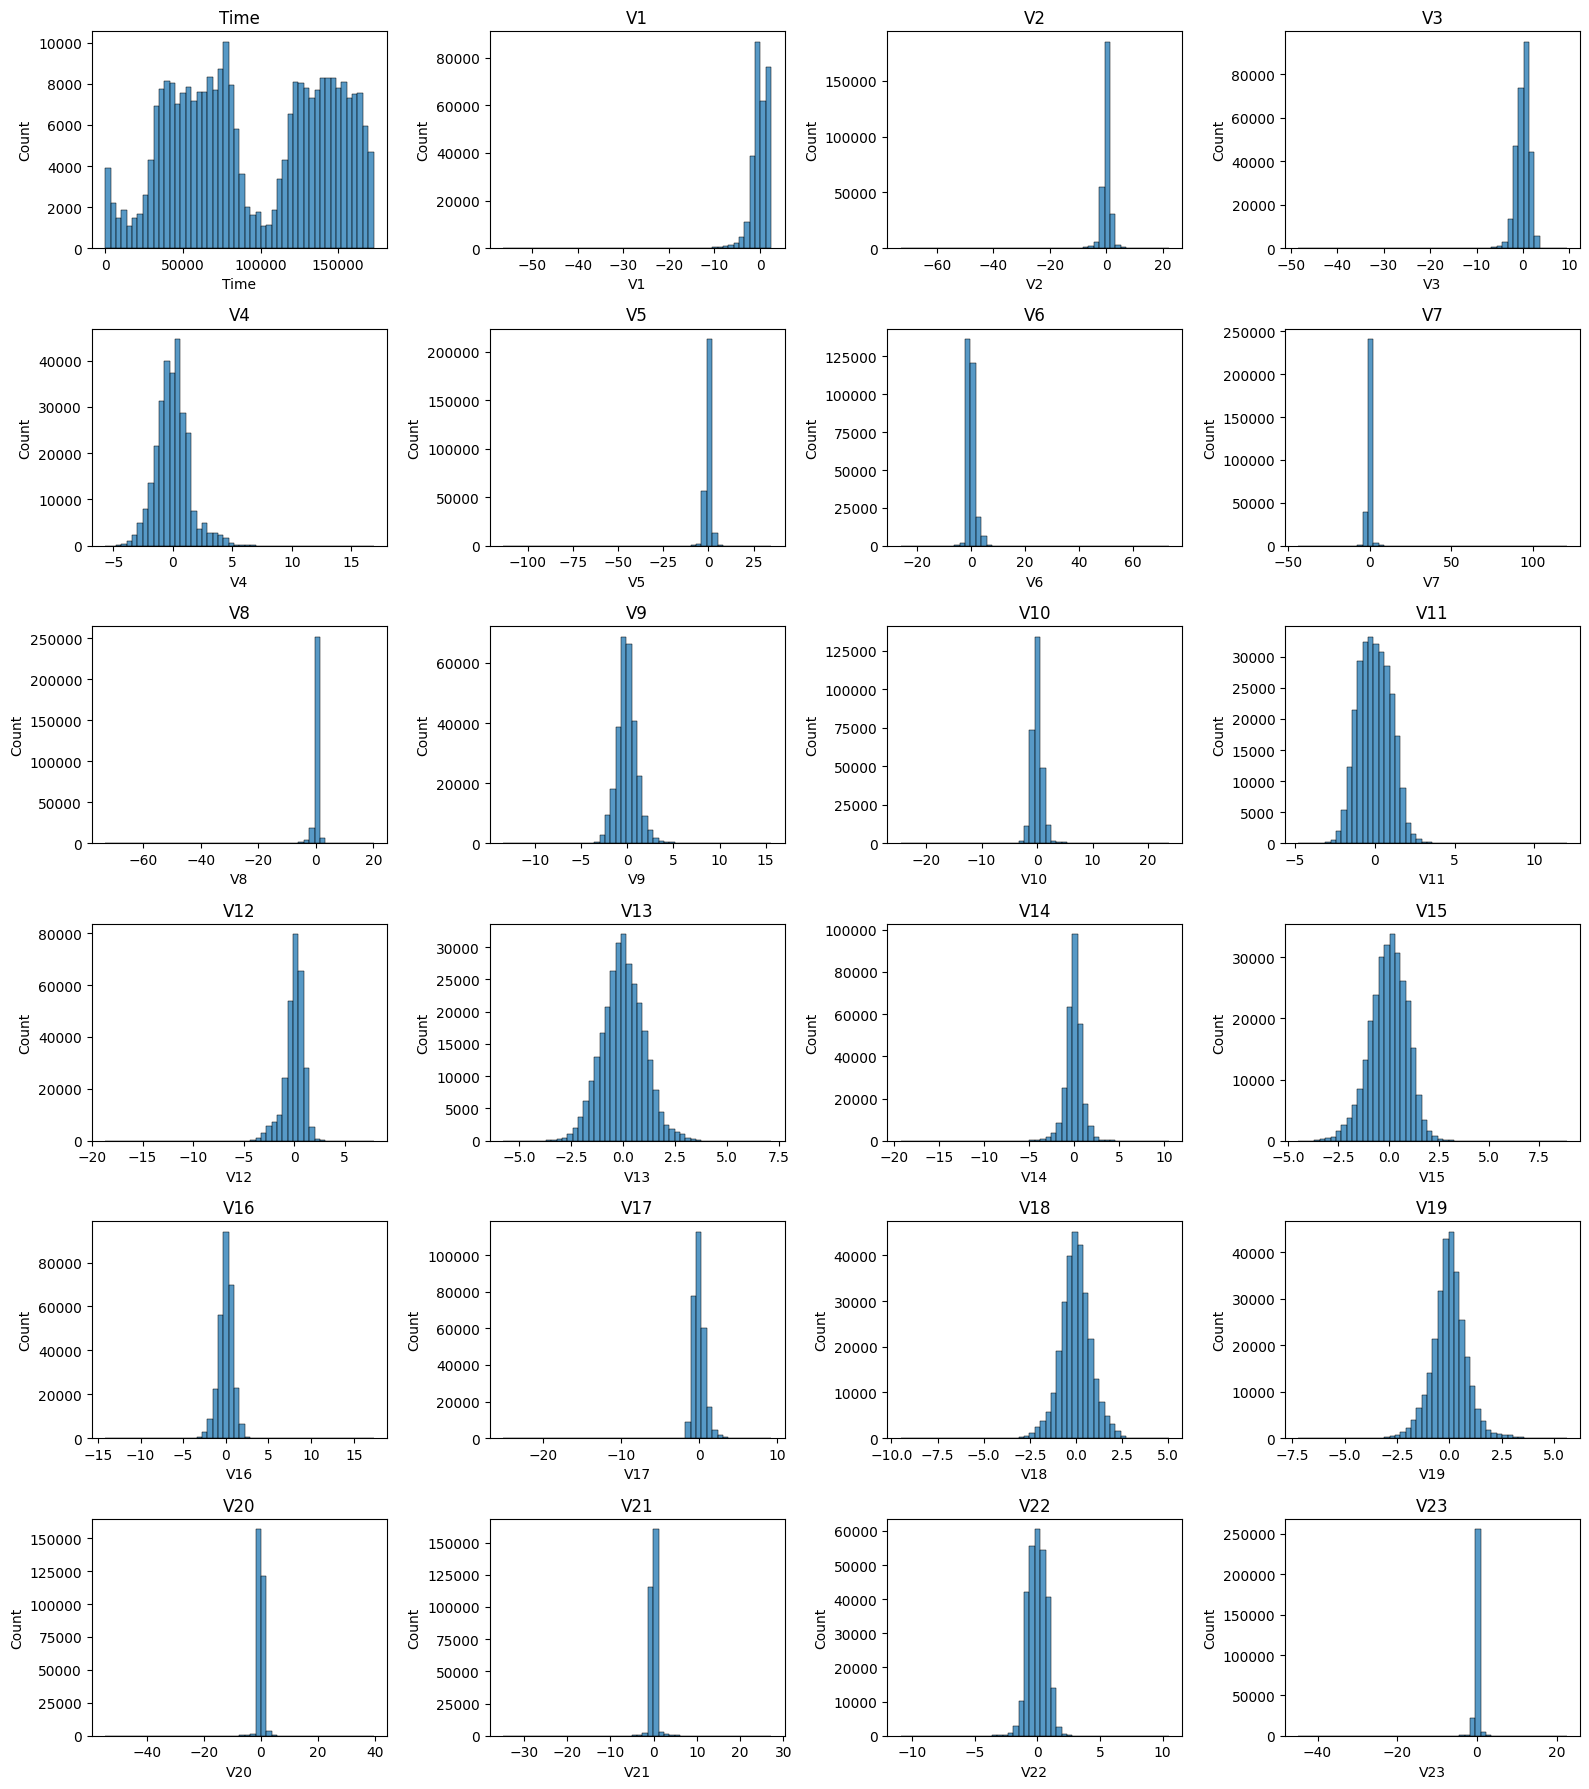

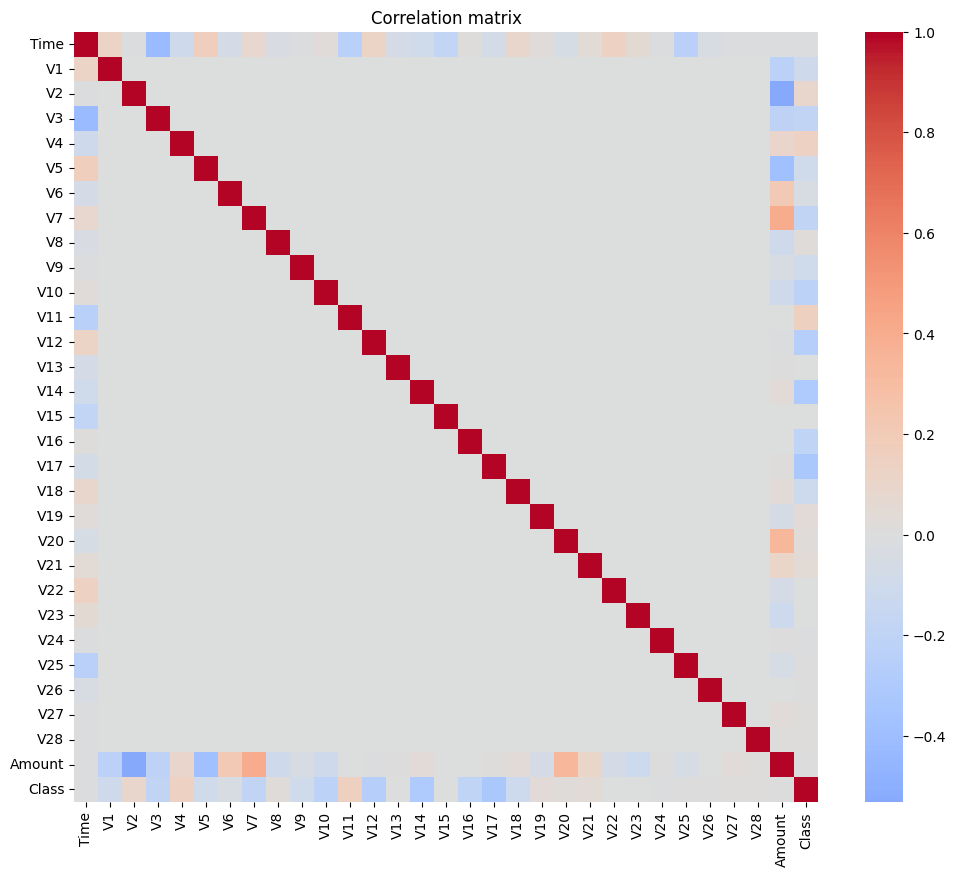

In [3]:
# Visualizations: distributions and correlation

num = df.select_dtypes(include=[np.number])

# Histograms (sample columns if too many)
cols_to_plot = num.columns.tolist()
max_cols = 24
if len(cols_to_plot) > max_cols:
    cols_to_plot = cols_to_plot[:max_cols]

fig, axes = plt.subplots(nrows=int(np.ceil(len(cols_to_plot)/4)), ncols=4, figsize=(16, 3 * int(np.ceil(len(cols_to_plot)/4))))
for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[len(cols_to_plot):]:
    ax.set_visible(False)
plt.tight_layout()

# Correlation heatmap for numeric features (if not too many)
if num.shape[1] <= 60:
    plt.figure(figsize=(12, 10))
    sns.heatmap(num.corr(), cmap='coolwarm', center=0)
    plt.title('Correlation matrix')
else:
    print('Too many numeric columns for full correlation heatmap — consider selecting features')

plt.show()

In [8]:
# Cleaning & feature engineering

def clean_and_engineer(df):
    df = df.copy()
    # drop fully empty columns
    empty_cols = [c for c in df.columns if df[c].isna().all()]
    if empty_cols:
        print('dropping empty columns:', empty_cols)
        df.drop(columns=empty_cols, inplace=True)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

    # impute numerics with median
    for c in num_cols:
        if df[c].isna().any():
            df[c].fillna(df[c].median(), inplace=True)

    # impute categoricals with mode
    for c in cat_cols:
        if df[c].isna().any():
            df[c].fillna(df[c].mode().iloc[0], inplace=True)

    # feature: log-transform Amount if present
    if 'Amount' in df.columns:
        df['Amount_log1p'] = np.log1p(df['Amount'].abs())

    return df

# apply
df_clean = clean_and_engineer(df)
print('after cleaning shape:', df_clean.shape)

# brief compare
print('missing values after cleaning (top):')
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

df_clean.head()

after cleaning shape: (284807, 32)
missing values after cleaning (top):
Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log1p
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539


In [9]:
# Scaling, train/test split, and class weights

# select target and features
if 'Class' not in df_clean.columns:
    raise RuntimeError("Expected column 'Class' as target")

X = df_clean.drop(columns=['Class'])
# one-hot encode categoricals if any
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

y = df_clean['Class'].astype(int)

# scale features
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# stratified split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# compute class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

print('train shape:', X_train.shape, 'test shape:', X_test.shape)
print('train target counts:')
print(y_train.value_counts())
print('\nclass_weights:', class_weights)

train shape: (227845, 31) test shape: (56962, 31)
train target counts:
Class
0    227451
1       394
Name: count, dtype: int64

class_weights: {0: 0.5008661206149896, 1: 289.14340101522845}


### Evaluation guidance and next steps

- Use `precision`, `recall`, `f1`, and PR-AUC (average precision) as primary metrics for imbalanced binary classification. Accuracy is misleading.
- For model training prefer cross-validation stratified by `Class` and log experiments with MLflow.
- Start with `class_weight` in tree-based models or `sample_weight` for sklearn estimators; compare with `train_smote` and `train_smote_tomek` variants.
- When using resampled data, always evaluate on the untouched `test.pkl` held-out set.



# **MLflow Experiment tracking for model selection**

In [3]:
import mlflow
import mlflow.sklearn


In [7]:
# check the tracking URI and experiment
print('MLflow tracking URI:', mlflow.get_tracking_uri())

MLflow tracking URI: sqlite:////workspaces/Projet-encadre/mlflow.db


In [8]:
mlflow.tracking.set_tracking_uri("http://localhost:5000")

In [9]:
mlflow.get_tracking_uri()

'http://localhost:5000'

In [2]:
#import classifiers and metrics for modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [5]:
from sklearn.metrics import precision_recall_curve, auc, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_validate
import warnings
warnings.filterwarnings('ignore')

# Helper function for evaluation
def evaluate_model(model, X_train_data, y_train_data, X_test_data, y_test_data, model_name):
    """Train and evaluate model with comprehensive metrics"""
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)
    y_pred_proba = model.predict_proba(X_test_data)[:, 1]
    
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)
    roc_auc = roc_auc_score(y_test_data, y_pred_proba)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_data, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    metrics = {
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
    return model, y_pred, y_pred_proba, metrics

# Store results
results = {}

# Model 1: Random Forest with class weights (baseline)
print("=" * 60)
print("Model 1: Random Forest with class weights")
print("=" * 60)

with mlflow.start_run(run_name="1-random-forest-class-weight") as run:
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("data_type", "original")
    
    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_model, rf_pred, rf_proba, rf_metrics = evaluate_model(rf_model, X_train, y_train, X_test, y_test, "RF")
    
    for metric, value in rf_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(rf_model, "model")
    results["Random Forest"] = rf_metrics

Model 1: Random Forest with class weights


NameError: name 'X_train' is not defined

In [13]:
# Model 2: Logistic Regression with class weights (baseline linear model)
print("\n" + "=" * 60)
print("Model 2: Logistic Regression with class weights")
print("=" * 60)

with mlflow.start_run(run_name="2-logistic-regression") as run:
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("data_type", "original")
    
    lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
    lr_model, lr_pred, lr_proba, lr_metrics = evaluate_model(lr_model, X_train, y_train, X_test, y_test, "LR")
    
    for metric, value in lr_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(lr_model, "model")
    results["Logistic Regression"] = lr_metrics


Model 2: Logistic Regression with class weights
Precision: 0.0614
Recall: 0.9184
F1: 0.1152
ROC-AUC: 0.9718


2026/06/11 10:01:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 10:01:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.7644


2026/06/11 10:01:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 10:01:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 10:01:24 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 10:01:24 INFO mlflow.utils.uv_utils: Exported 182 dependencies via uv
2026/06/11 10:01:24 INFO mlflow.utils.environment: Successfully exported 182 requirements from uv project. Skipping package capture based inference.
2026/06/11 10:01:25 WARNING mlflow.utils.environment: Failed to resolve installed pi

🏃 View run 2-logistic-regression at: http://localhost:5000/#/experiments/0/runs/5981c0c48fa0423bb338c5dcf6c891a0
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [14]:
# Model 3: Gradient Boosting Classifier
print("\n" + "=" * 60)
print("Model 3: Gradient Boosting Classifier")
print("=" * 60)

from sklearn.ensemble import GradientBoostingClassifier

with mlflow.start_run(run_name="3-gradient-boosting") as run:
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("data_type", "original")
    
    gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    gb_model, gb_pred, gb_proba, gb_metrics = evaluate_model(gb_model, X_train, y_train, X_test, y_test, "GB")
    
    for metric, value in gb_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(gb_model, "model")
    results["Gradient Boosting"] = gb_metrics


Model 3: Gradient Boosting Classifier
Precision: 0.7975
Recall: 0.6429
F1: 0.7119
ROC-AUC: 0.7418


2026/06/11 10:09:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 10:09:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.5857


2026/06/11 10:09:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 10:09:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 10:09:25 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 10:09:25 INFO mlflow.utils.uv_utils: Exported 182 dependencies via uv
2026/06/11 10:09:25 INFO mlflow.utils.environment: Successfully exported 182 requirements from uv project. Skipping package capture based inference.
2026/06/11 10:09:26 WARNING mlflow.utils.environment: Failed to resolve installed pi

🏃 View run 3-gradient-boosting at: http://localhost:5000/#/experiments/0/runs/1580c74b2ffb407eaf7d410d18abeadf
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [15]:
# Model 4: Extra Trees Classifier
print("\n" + "=" * 60)
print("Model 4: Extra Trees Classifier")
print("=" * 60)

from sklearn.ensemble import ExtraTreesClassifier

with mlflow.start_run(run_name="4-extra-trees") as run:
    mlflow.log_param("model_type", "ExtraTrees")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("data_type", "original")
    
    et_model = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    et_model, et_pred, et_proba, et_metrics = evaluate_model(et_model, X_train, y_train, X_test, y_test, "ET")
    
    for metric, value in et_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(et_model, "model")
    results["Extra Trees"] = et_metrics


Model 4: Extra Trees Classifier
Precision: 0.9512
Recall: 0.7959
F1: 0.8667
ROC-AUC: 0.9526


2026/06/11 10:09:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 10:09:54 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.8886


2026/06/11 10:09:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 10:09:54 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 10:09:54 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 10:09:54 INFO mlflow.utils.uv_utils: Exported 182 dependencies via uv
2026/06/11 10:09:54 INFO mlflow.utils.environment: Successfully exported 182 requirements from uv project. Skipping package capture based inference.
2026/06/11 10:09:55 WARNING mlflow.utils.environment: Failed to resolve installed pi

🏃 View run 4-extra-trees at: http://localhost:5000/#/experiments/0/runs/e26e8062a87c477da9dd4dc43438ae29
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [16]:
# Model 5: XGBoost Classifier
print("\n" + "=" * 60)
print("Model 5: XGBoost Classifier")
print("=" * 60)

try:
    import xgboost as xgb
    
    # Calculate scale_pos_weight for imbalanced data
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    
    with mlflow.start_run(run_name="5-xgboost") as run:
        mlflow.log_param("model_type", "XGBoost")
        mlflow.log_param("n_estimators", 100)
        mlflow.log_param("max_depth", 6)
        mlflow.log_param("scale_pos_weight", scale_pos_weight)
        mlflow.log_param("data_type", "original")
        
        xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=scale_pos_weight, 
                                       random_state=42, n_jobs=-1, verbosity=0)
        xgb_model, xgb_pred, xgb_proba, xgb_metrics = evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGB")
        
        for metric, value in xgb_metrics.items():
            mlflow.log_metric(metric, value)
            print(f"{metric}: {value:.4f}")
        
        mlflow.sklearn.log_model(xgb_model, "model")
        results["XGBoost"] = xgb_metrics
except ImportError:
    print("XGBoost not installed, skipping this model")


Model 5: XGBoost Classifier
Precision: 0.8817
Recall: 0.8367
F1: 0.8586
ROC-AUC: 0.9682


2026/06/11 10:10:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 10:10:09 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre


PR-AUC: 0.8799


2026/06/11 10:10:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/11 10:10:10 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /workspaces/Projet-encadre
2026/06/11 10:10:10 INFO mlflow.utils.environment: Detected uv project at /workspaces/Projet-encadre. Attempting to export requirements via 'uv export'.
2026/06/11 10:10:10 INFO mlflow.utils.uv_utils: Exported 182 dependencies via uv
2026/06/11 10:10:10 INFO mlflow.utils.environment: Successfully exported 182 requirements from uv project. Skipping package capture based inference.
2026/06/11 10:10:10 WARNING mlflow.utils.environment: Failed to resolve installed pi

🏃 View run 5-xgboost at: http://localhost:5000/#/experiments/0/runs/787c806cf245470c85bc2c93bc7f71e1
🧪 View experiment at: http://localhost:5000/#/experiments/0


In [17]:
# Model 6: LightGBM Classifier
print("\n" + "=" * 60)
print("Model 6: LightGBM Classifier")
print("=" * 60)

try:
    import lightgbm as lgb
    
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    
    with mlflow.start_run(run_name="6-lightgbm") as run:
        mlflow.log_param("model_type", "LightGBM")
        mlflow.log_param("n_estimators", 100)
        mlflow.log_param("max_depth", 6)
        mlflow.log_param("scale_pos_weight", scale_pos_weight)
        mlflow.log_param("data_type", "original")
        
        lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=6, scale_pos_weight=scale_pos_weight,
                                        random_state=42, n_jobs=-1, verbosity=-1)
        lgb_model, lgb_pred, lgb_proba, lgb_metrics = evaluate_model(lgb_model, X_train, y_train, X_test, y_test, "LGB")
        
        for metric, value in lgb_metrics.items():
            mlflow.log_metric(metric, value)
            print(f"{metric}: {value:.4f}")
        
        mlflow.sklearn.log_model(lgb_model, "model")
        results["LightGBM"] = lgb_metrics
except ImportError:
    print("LightGBM not installed, skipping this model")


Model 6: LightGBM Classifier
LightGBM not installed, skipping this model


In [4]:
# Model 8: AdaBoost Classifier
print("\n" + "=" * 60)
print("Model 8: AdaBoost Classifier")
print("=" * 60)

from sklearn.ensemble import AdaBoostClassifier

with mlflow.start_run(run_name="8-adaboost") as run:
    mlflow.log_param("model_type", "AdaBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.8)
    mlflow.log_param("data_type", "original")
    
    # AdaBoost with Decision Tree base estimator
    from sklearn.tree import DecisionTreeClassifier
    ada_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100, 
                                    learning_rate=0.8, random_state=42)
    ada_model, ada_pred, ada_proba, ada_metrics = evaluate_model(ada_model, X_train, y_train, X_test, y_test, "Ada")
    
    for metric, value in ada_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(ada_model, "model")
    results["AdaBoost"] = ada_metrics


Model 8: AdaBoost Classifier


NameError: name 'evaluate_model' is not defined

In [ ]:
# Model 7: Support Vector Machine (SVM) - Using Linear kernel for speed
print("\n" + "=" * 60)
print("Model 7: Support Vector Machine (SVM) - Linear Kernel")
print("=" * 60)

from sklearn.svm import SVC

with mlflow.start_run(run_name="7-svm-linear") as run:
    mlflow.log_param("model_type", "SVM")
    mlflow.log_param("kernel", "linear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("data_type", "original")
    
    # Using linear kernel for faster training
    svm_model = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42, max_iter=2000)
    svm_model, svm_pred, svm_proba, svm_metrics = evaluate_model(svm_model, X_train, y_train, X_test, y_test, "SVM")
    
    for metric, value in svm_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(svm_model, "model")
    results["SVM Linear"] = svm_metrics


Model 7: Support Vector Machine (SVM) - Linear Kernel


In [ ]:
# Model 9: Neural Network (MLP Classifier)
print("\n" + "=" * 60)
print("Model 9: Neural Network (MLP Classifier)")
print("=" * 60)

from sklearn.neural_network import MLPClassifier

with mlflow.start_run(run_name="9-mlp-neural-network") as run:
    mlflow.log_param("model_type", "MLPClassifier")
    mlflow.log_param("hidden_layer_sizes", "(100, 50)")
    mlflow.log_param("activation", "relu")
    mlflow.log_param("max_iter", 500)
    mlflow.log_param("data_type", "original")
    
    mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=500, 
                              random_state=42, early_stopping=True, validation_fraction=0.1)
    mlp_model, mlp_pred, mlp_proba, mlp_metrics = evaluate_model(mlp_model, X_train, y_train, X_test, y_test, "MLP")
    
    for metric, value in mlp_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(mlp_model, "model")
    results["MLP Neural Network"] = mlp_metrics

In [ ]:
# Model 10: Balanced Bagging Classifier
print("\n" + "=" * 60)
print("Model 10: Balanced Bagging Classifier")
print("=" * 60)

from imblearn.ensemble import BalancedBaggingClassifier

with mlflow.start_run(run_name="10-balanced-bagging") as run:
    mlflow.log_param("model_type", "BalancedBagging")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("sampling_strategy", "auto")
    mlflow.log_param("data_type", "original")
    
    bb_model = BalancedBaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    bb_model, bb_pred, bb_proba, bb_metrics = evaluate_model(bb_model, X_train, y_train, X_test, y_test, "BB")
    
    for metric, value in bb_metrics.items():
        mlflow.log_metric(metric, value)
        print(f"{metric}: {value:.4f}")
    
    mlflow.sklearn.log_model(bb_model, "model")
    results["Balanced Bagging"] = bb_metrics

In [ ]:
# Model Comparison Summary
print("\n" + "=" * 80)
print("MODELS COMPARISON SUMMARY")
print("=" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
print(comparison_df)

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Performance Comparison on Credit Card Fraud Detection', fontsize=14, fontweight='bold')

metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
for idx, metric in enumerate(metrics_to_plot):
    if idx < 5:
        ax = axes[idx // 3, idx % 3]
        values = comparison_df[metric].sort_values(ascending=False)
        colors = ['#2ecc71' if v == values.max() else '#3498db' for v in values.values]
        ax.barh(range(len(values)), values.values, color=colors)
        ax.set_yticks(range(len(values)))
        ax.set_yticklabels(values.index, fontsize=9)
        ax.set_xlabel(metric, fontsize=10)
        ax.set_title(f'{metric} by Model', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.set_xlim([0, 1.0])
        
        # Add value labels on bars
        for i, v in enumerate(values.values):
            ax.text(v - 0.03, i, f'{v:.3f}', va='center', ha='right', fontsize=8, fontweight='bold')

# Remove extra subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

# Find best model for each metric
print("\n" + "=" * 80)
print("BEST MODELS BY METRIC")
print("=" * 80)
for metric in metrics_to_plot:
    best_model = comparison_df[metric].idxmax()
    best_score = comparison_df[metric].max()
    print(f"{metric:10s}: {best_model:25s} ({best_score:.4f})")

# Overall ranking by F1 score (balanced metric)
print("\n" + "=" * 80)
print("OVERALL RANKING (by F1-Score)")
print("=" * 80)
ranking = comparison_df['F1'].sort_values(ascending=False)
for idx, (model, score) in enumerate(ranking.items(), 1):
    print(f"{idx:2d}. {model:25s} - F1: {score:.4f}")